# Flood Risk & Building Claims Analysis  
**Research Question:** Can we use flood exposure predict building claim losses?  

### Baseline Models
- **Model A:** Linear Regression → predict `log1p(amountPaidOnBuildingClaim)`
- **Model B:** Logistic Regression → predict high/low loss (above/below median)
- **Model C:** Random Forest Regressor → same target as A
- **Model D:** Random Forest Classifier → same target as B

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
)

In [2]:
# define file paths
paths = {
    'model_data': '../data/processed/cleaned_model_data.csv'
}

In [3]:
# import data
df_model = pd.read_csv(paths['model_data'])

#### Prep X and y for Modeling

In [4]:
X = df_model.drop(columns=['log_claim', 'high_loss'])

y_A = df_model['log_claim'] # regression target
y_B = df_model['high_loss'] # classification target (1 if claim > 10k, else 0)

continuous_features = ['waterDepth', 'building_age']

In [5]:
X.columns

Index(['waterDepth', 'building_age', 'totalBuildingInsuranceCoverage',
       'elevated', 'post_firm', 'is_residential', 'primary_residence',
       'zone_Low', 'zone_Moderate', 'county_37065', 'county_37107',
       'county_37155', 'county_37191', 'event_Hurricane Bonnie',
       'event_Hurricane Debby', 'event_Hurricane Dennis',
       'event_Hurricane Eta', 'event_Hurricane Florence',
       'event_Hurricane Floyd', 'event_Hurricane Fran',
       'event_Hurricane Irene', 'event_Hurricane Isabel',
       'event_Hurricane Matthew', 'event_Other',
       'event_Tropical Storm Ernesto', 'event_Tropical Storm Ophelia',
       'event_Unknown'],
      dtype='str')

#### Train/Test Split & Normalization

In [6]:
X_train, X_test, yA_train, yA_test, yB_train, yB_test = train_test_split(
    X, y_A, y_B, test_size=0.2, random_state=42
)
print(f'Train size: {len(X_train)}')
print(f'Test size:  {len(X_test)}')

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_test_scaled[continuous_features]  = scaler.transform(X_test[continuous_features])


before = X_train[continuous_features].values.max(axis=0) - X_train[continuous_features].values.min(axis=0)
after  = X_train_scaled[continuous_features].values.max(axis=0) - X_train_scaled[continuous_features].values.min(axis=0)
print(f'\nRange before scaling: {before.round(2)}')
print(f'Range after scaling:  {after.round(2)}')

Train size: 9082
Test size:  2271

Range before scaling: [ 63. 221.]
Range after scaling:  [8.28 9.72]


#### Compare Baseline Models

In [7]:
#Model A — Linear Regression

lr = LinearRegression()
lr.fit(X_train_scaled, yA_train)

yA_pred_train = lr.predict(X_train_scaled)
yA_pred_test  = lr.predict(X_test_scaled)

r2_train  = r2_score(yA_train, yA_pred_train)
r2_test   = r2_score(yA_test,  yA_pred_test)
rmse_test = np.sqrt(mean_squared_error(yA_test, yA_pred_test))
rmse_usd  = np.sqrt(mean_squared_error(np.expm1(yA_test), np.expm1(yA_pred_test)))

print('=== Model A: Linear Regression ===')
print(f'R²  (train): {r2_train:.4f}')
print(f'R²  (test):  {r2_test:.4f}')
print(f'RMSE (test): ~${rmse_usd:,.0f}  [USD scale]')

=== Model A: Linear Regression ===
R²  (train): 0.1699
R²  (test):  0.1301
RMSE (test): ~$35,576  [USD scale]


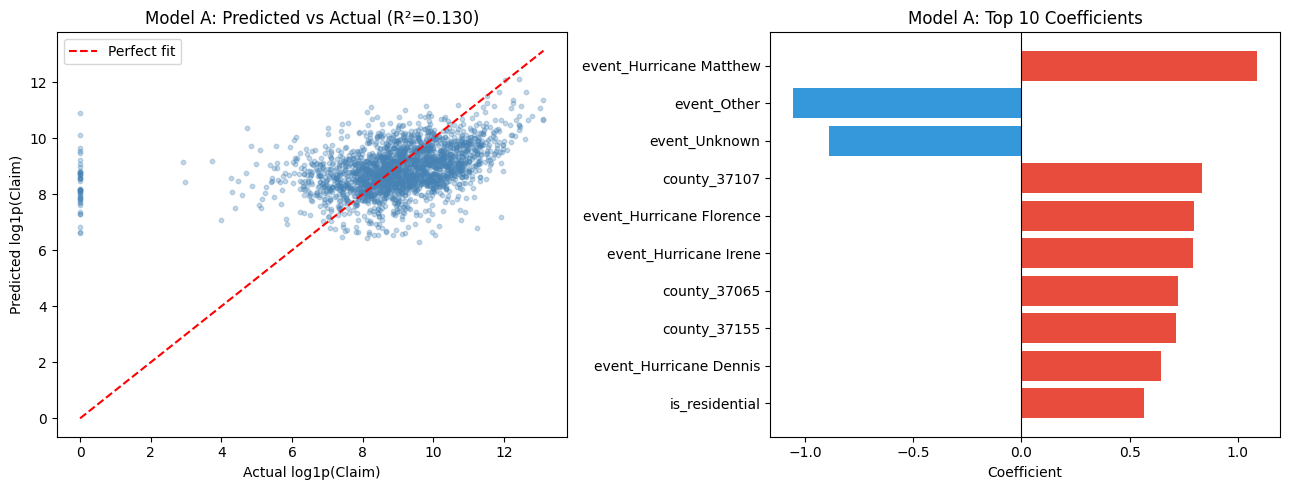

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(yA_test, yA_pred_test, alpha=0.3, s=10, color='steelblue')
lims = [min(yA_test.min(), yA_pred_test.min()), max(yA_test.max(), yA_pred_test.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual log1p(Claim)'); axes[0].set_ylabel('Predicted log1p(Claim)')
axes[0].set_title(f'Model A: Predicted vs Actual (R²={r2_test:.3f})'); axes[0].legend()

coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr.coef_}).sort_values('Coefficient', key=abs, ascending=False)
top10 = coef_df.head(10)
colors = ['#e74c3c' if c > 0 else '#3498db' for c in top10['Coefficient']]
axes[1].barh(top10['Feature'], top10['Coefficient'], color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Model A: Top 10 Coefficients'); axes[1].set_xlabel('Coefficient')
axes[1].invert_yaxis()

plt.tight_layout(); plt.show()

In [9]:
# Model B — Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, yB_train)

yB_prob = log_reg.predict_proba(X_test_scaled)[:, 1]
yB_pred = (yB_prob >= 0.5).astype(int)

print('=== Model B: Logistic Regression (threshold=0.5) ===')
print(f'Accuracy:  {accuracy_score(yB_test, yB_pred):.4f}')
print(f'Precision: {precision_score(yB_test, yB_pred):.4f}')
print(f'Recall:    {recall_score(yB_test, yB_pred):.4f}')
print(f'F1 Score:  {f1_score(yB_test, yB_pred):.4f}')

=== Model B: Logistic Regression (threshold=0.5) ===
Accuracy:  0.6759
Precision: 0.6715
Recall:    0.6358
F1 Score:  0.6532


/Users/zyliazhang/Git/PROJECT-flood-risk-modeling/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
# Model C: Random Forest Regressor
rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train_scaled, yA_train)

rfA_pred_train = rf_reg.predict(X_train_scaled)
rfA_pred_test  = rf_reg.predict(X_test_scaled)

rfA_r2_train = r2_score(yA_train, rfA_pred_train)
rfA_r2_test  = r2_score(yA_test,  rfA_pred_test)
rfA_rmse     = np.sqrt(mean_squared_error(yA_test, rfA_pred_test))
rfA_rmse_usd = np.sqrt(mean_squared_error(np.expm1(yA_test), np.expm1(rfA_pred_test)))

print('=== Model C: Random Forest Regressor ===')
print(f'R²  (train): {rfA_r2_train:.4f}')
print(f'R²  (test):  {rfA_r2_test:.4f}')
print(f'RMSE (test): {rfA_rmse:.4f}  [log1p scale]')
print(f'RMSE (test): ~${rfA_rmse_usd:,.0f}  [USD scale]')
print()
print('=== vs Model A (Linear Regression) ===')
print(f'R²   improvement: {rfA_r2_test - r2_test:+.4f}')
print(f'RMSE improvement: ${rfA_rmse_usd - rmse_usd:+,.0f} USD')

=== Model C: Random Forest Regressor ===
R²  (train): 0.4425
R²  (test):  0.3685
RMSE (test): 1.4925  [log1p scale]
RMSE (test): ~$31,183  [USD scale]

=== vs Model A (Linear Regression) ===
R²   improvement: +0.2384
RMSE improvement: $-4,392 USD


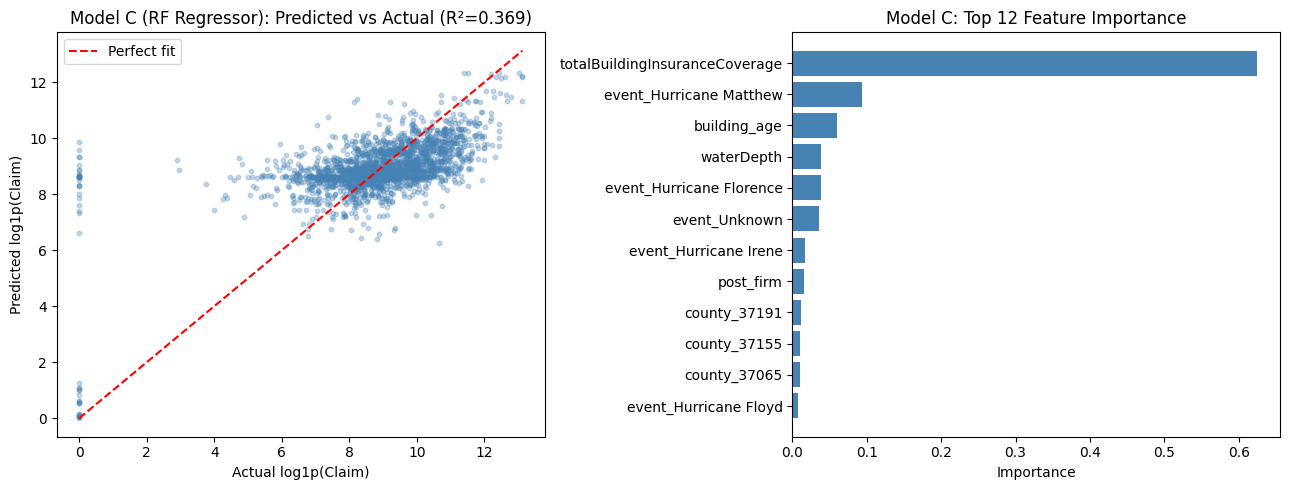

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(yA_test, rfA_pred_test, alpha=0.3, s=10, color='steelblue')
lims = [min(yA_test.min(), rfA_pred_test.min()), max(yA_test.max(), rfA_pred_test.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual log1p(Claim)'); axes[0].set_ylabel('Predicted log1p(Claim)')
axes[0].set_title(f'Model C (RF Regressor): Predicted vs Actual (R²={rfA_r2_test:.3f})')
axes[0].legend()

feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': rf_reg.feature_importances_}).sort_values('Importance', ascending=False)
axes[1].barh(feat_imp['Feature'].head(12), feat_imp['Importance'].head(12), color='steelblue')
axes[1].set_title('Model C: Top 12 Feature Importance')
axes[1].set_xlabel('Importance'); axes[1].invert_yaxis()

plt.tight_layout(); plt.show()

In [12]:
# Model D: Random Forest Classifier
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train_scaled, yB_train)

rfB_prob = rf_clf.predict_proba(X_test_scaled)[:, 1]
rfB_pred = (rfB_prob >= 0.5).astype(int)

rfB_acc  = accuracy_score(yB_test, rfB_pred)
rfB_prec = precision_score(yB_test, rfB_pred)
rfB_rec  = recall_score(yB_test, rfB_pred)
rfB_f1   = f1_score(yB_test, rfB_pred)

print('=== Model D: Random Forest Classifier (threshold=0.5) ===')
print(f'Accuracy:  {rfB_acc:.4f}')
print(f'Precision: {rfB_prec:.4f}')
print(f'Recall:    {rfB_rec:.4f}')
print(f'F1 Score:  {rfB_f1:.4f}')

=== Model D: Random Forest Classifier (threshold=0.5) ===
Accuracy:  0.7028
Precision: 0.7036
Recall:    0.6578
F1 Score:  0.6799


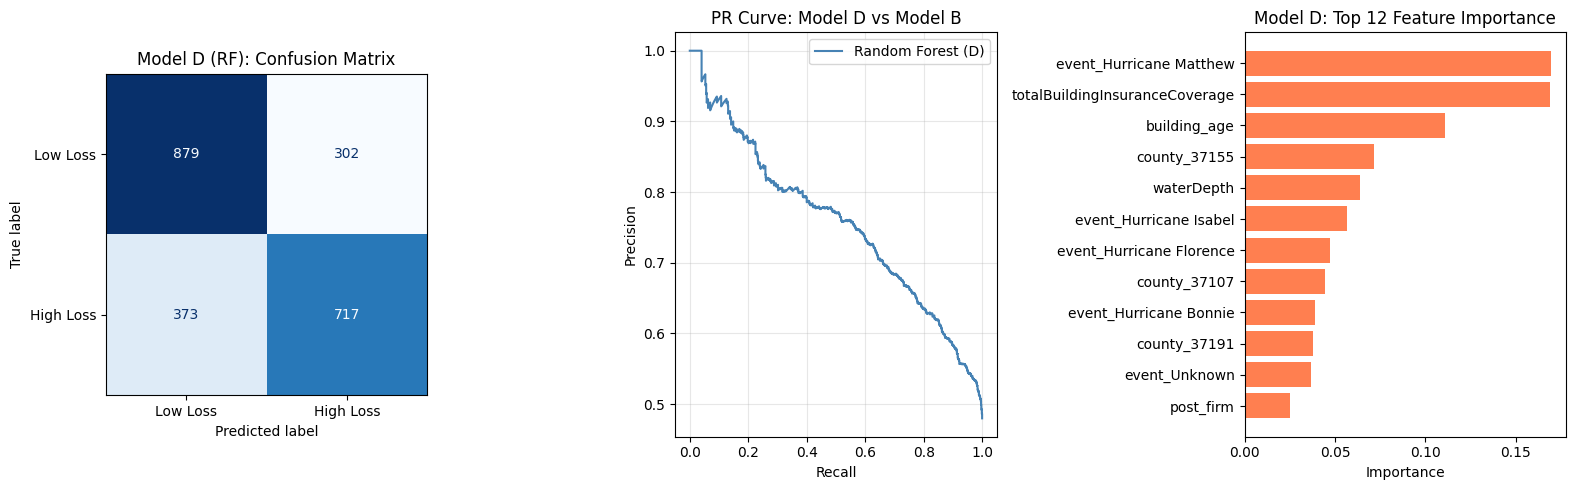

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cm_rf = confusion_matrix(yB_test, rfB_pred)
ConfusionMatrixDisplay(cm_rf, display_labels=['Low Loss','High Loss']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Model D (RF): Confusion Matrix')

prec_rf, rec_rf, _ = precision_recall_curve(yB_test, rfB_prob)
axes[1].plot(rec_rf, prec_rf, color='steelblue', linewidth=1.5, label='Random Forest (D)')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curve: Model D vs Model B'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

feat_imp_clf = pd.DataFrame({'Feature': X.columns, 'Importance': rf_clf.feature_importances_}).sort_values('Importance', ascending=False)
axes[2].barh(feat_imp_clf['Feature'].head(12), feat_imp_clf['Importance'].head(12), color='coral')
axes[2].set_title('Model D: Top 12 Feature Importance')
axes[2].set_xlabel('Importance'); axes[2].invert_yaxis()

plt.tight_layout(); plt.show()

#### Baseline Model Summary

In [ ]:
print('=' * 60)
print('FINAL MODEL COMPARISON')
print('=' * 60)
print(f'{"Model":<6} {"Type":<25} {"Metric 1":<20} {"Metric 2"}')
print('-' * 60)
print(f'{"A":<6} {"Linear Regression":<25} {f"R²={r2_test:.4f}":<20} {f"RMSE=${rmse_usd:,.0f}"}')
print(f'{"B":<6} {"Logistic Regression":<25} {f"Acc={accuracy_score(yB_test,yB_pred):.4f}":<20} {f"F1={f1_score(yB_test,yB_pred):.4f}"}')
print(f'{"C":<6} {"RF Regressor":<25} {f"R²={rfA_r2_test:.4f}":<20} {f"RMSE=${rfA_rmse_usd:,.0f}"}')
print(f'{"D":<6} {"RF Classifier":<25} {f"Acc={rfB_acc:.4f}":<20} {f"F1={rfB_f1:.4f}"}')
print('=' * 60)

FINAL MODEL COMPARISON
Model  Type                      Metric 1             Metric 2
------------------------------------------------------------
A      Linear Regression         R²=0.1301            RMSE=$35,576
B      Logistic Regression       Acc=0.6759           F1=0.6532
C      RF Regressor              R²=0.3685            RMSE=$31,183
D      RF Classifier             Acc=0.7028           F1=0.6799


#### Limitations
- FEMA coordinates privacy-masked to 0.1° (~11km) — precise spatial joins not possible
- features excluded if having null values
- Claims data covers insured properties only: uninsured losses not captured
- Median split for Model B/D is data-driven, not domain-defined